# 5b. PyTorch Fundamentals & Tensors
---

So far we have built everything from scratch with NumPy. From here on we use **PyTorch** — the industry-standard deep learning framework. This notebook covers everything you need to be productive with it.

<img src="./Images/tensor.webp" width="500" height="500" />

## 5b.1 What is a Tensor?

A **tensor** is just a multi-dimensional array — exactly like a NumPy array, but with two superpowers:
1. It can live on a **GPU** for massive speedups
2. It can track every operation for **automatic differentiation** (autograd)

| Rank | Name | Example shape |
|------|------|--------------|
| 0 | Scalar | `()` |
| 1 | Vector | `(n,)` |
| 2 | Matrix | `(rows, cols)` |
| 3 | 3-D tensor | `(batch, H, W)` |
| 4 | 4-D tensor | `(batch, C, H, W)` — images |

A tensor is a mathematical object that generalizes scalars, vectors, and matrices to higher dimensions, acting as a container for numerical data. (Google)

<br> https://towardsdatascience.com/what-is-a-tensor-in-deep-learning-6dedd95d6507 </br>


In [1]:
import sys
print(sys.executable)

/Users/samson.afolabi/Documents/DSR/Deep_Learning_Notebooks/deep_learning_311/bin/python3


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ── Creating tensors ──
t_zeros = torch.zeros(3, 4)
t_ones  = torch.ones(2, 3)
t_rand  = torch.rand(3, 3)        # uniform [0,1)
t_randn = torch.randn(3, 3)       # standard normal
t_range = torch.arange(0, 10, 2)  # like np.arange
t_from_list = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

print("\n=== Tensor creation ===")
print(f"zeros(3,4):       shape={t_zeros.shape}, dtype={t_zeros.dtype}")
print(f"rand(3,3):        shape={t_rand.shape}")
print(f"arange(0,10,2):   {t_range}")
print(f"from list:\n{t_from_list}")

PyTorch version: 2.11.0
Device: cpu

=== Tensor creation ===
zeros(3,4):       shape=torch.Size([3, 4]), dtype=torch.float32
rand(3,3):        shape=torch.Size([3, 3])
arange(0,10,2):   tensor([0, 2, 4, 6, 8])
from list:
tensor([[1., 2.],
        [3., 4.]])


In [6]:
# ── Tensor properties ──
x = torch.randn(4, 3)
print(f"Shape:   {x.shape}")        # like np.shape
print(f"Size:    {x.size()}")       # same as shape
print(f"Dtype:   {x.dtype}")
print(f"Device:  {x.device}")
print(f"Numel:   {x.numel()}")      # total number of elements

# ── Reshaping ──
x_flat  = x.reshape(-1)            # flatten to 1D
x_t     = x.T                      # transpose
x_view  = x.view(2, 6)            # reshape (shares memory)
x_unsq  = x.unsqueeze(0)          # add dimension at axis 0

print(f"\nx shape:           {x.shape}")
print(f"x.reshape(-1):     {x_flat.shape}")
print(f"x.T:               {x_t.shape}")
print(f"x.view(2,6):       {x_view.shape}")
print(f"x.unsqueeze(0):    {x_unsq.shape}")


Shape:   torch.Size([4, 3])
Size:    torch.Size([4, 3])
Dtype:   torch.float32
Device:  cpu
Numel:   12

x shape:           torch.Size([4, 3])
x.reshape(-1):     torch.Size([12])
x.T:               torch.Size([3, 4])
x.view(2,6):       torch.Size([2, 6])
x.unsqueeze(0):    torch.Size([1, 4, 3])


In [7]:
# ── Basic operations ──
a = torch.tensor([[1., 2.], [3., 4.]])
b = torch.tensor([[5., 6.], [7., 8.]])

print("Element-wise add:  \n", a + b)
print("Element-wise mul:  \n", a * b)
print("Matrix multiply:   \n", a @ b)       # or torch.matmul(a, b)
print("Sum all:           ", a.sum().item())
print("Mean:              ", a.mean().item())
print("Max per column:    ", a.max(dim=0).values)

# Broadcasting (same as NumPy)
c = torch.ones(3, 1)
d = torch.ones(1, 4)
print(f"\nBroadcasting: {c.shape} + {d.shape} = {(c + d).shape}")


Element-wise add:  
 tensor([[ 6.,  8.],
        [10., 12.]])
Element-wise mul:  
 tensor([[ 5., 12.],
        [21., 32.]])
Matrix multiply:   
 tensor([[19., 22.],
        [43., 50.]])
Sum all:            10.0
Mean:               2.5
Max per column:     tensor([3., 4.])

Broadcasting: torch.Size([3, 1]) + torch.Size([1, 4]) = torch.Size([3, 4])


In [8]:
# ── NumPy ↔ PyTorch ──
np_array = np.array([1., 2., 3., 4.])
torch_from_np = torch.from_numpy(np_array)      # shares memory!
back_to_np    = torch_from_np.numpy()

print("NumPy → Tensor:", torch_from_np)
print("Tensor → NumPy:", back_to_np)
print("Shares memory: modifying one changes the other")
np_array[0] = 99
print(f"After np_array[0]=99 → tensor[0]={torch_from_np[0].item()}")


NumPy → Tensor: tensor([1., 2., 3., 4.], dtype=torch.float64)
Tensor → NumPy: [1. 2. 3. 4.]
Shares memory: modifying one changes the other
After np_array[0]=99 → tensor[0]=99.0


## 5b.2 Autograd — Automatic Differentiation

PyTorch records every operation on tensors with `requires_grad=True` and builds a **computational graph**.
Calling `.backward()` traverses this graph backwards and computes all gradients automatically.

This is the same chain rule from Notebook 6 — PyTorch just does it for you.


In [9]:
# ── requires_grad and .backward() ──
# Simple example: z = (w*x + b - y)²  →  find ∂z/∂w and ∂z/∂b

x = torch.tensor(2.0)
y = torch.tensor(5.0)   # target
w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Forward pass
pred = w * x + b        # = 2w + b
loss = (pred - y) ** 2  # MSE

print(f"w={w.item()}, b={b.item()}")
print(f"pred = {pred.item()}, y = {y.item()}")
print(f"loss = {loss.item()}")

# Backward pass — autograd computes gradients
loss.backward()

print(f"\n∂loss/∂w = {w.grad.item():.4f}   (manual: 2*(pred-y)*x = {2*(pred.item()-y.item())*x.item():.4f})")
print(f"∂loss/∂b = {b.grad.item():.4f}   (manual: 2*(pred-y)*1 = {2*(pred.item()-y.item()):.4f})")


w=1.0, b=0.0
pred = 2.0, y = 5.0
loss = 9.0

∂loss/∂w = -12.0000   (manual: 2*(pred-y)*x = -12.0000)
∂loss/∂b = -6.0000   (manual: 2*(pred-y)*1 = -6.0000)


In [10]:
# ── Gradient accumulation gotcha ──
w = torch.tensor(1.0, requires_grad=True)
x = torch.tensor(2.0)

for step in range(3):
    loss = (w * x) ** 2
    loss.backward()
    print(f"Step {step+1}: w.grad = {w.grad.item():.2f}  ← {'accumulating! call zero_grad()' if step > 0 else 'correct'}")

print("\nFix: call w.grad.zero_() (or optimizer.zero_grad()) before each backward")


Step 1: w.grad = 8.00  ← correct
Step 2: w.grad = 16.00  ← accumulating! call zero_grad()
Step 3: w.grad = 24.00  ← accumulating! call zero_grad()

Fix: call w.grad.zero_() (or optimizer.zero_grad()) before each backward


In [11]:
# ── Detaching from the graph ──
w = torch.tensor(3.0, requires_grad=True)
y = w ** 2

# If you just want the value, not the gradient
y_val = y.detach()      # breaks the graph — now just a plain tensor
y_np  = y.detach().numpy()

print(f"y (with grad):    {y}")
print(f"y.detach():       {y_val}  (no grad_fn)")
print(f"y.detach().numpy(): {y_np}")

# torch.no_grad() context — used during evaluation
with torch.no_grad():
    z = w * 2 + 1
    print(f"Inside no_grad: z.requires_grad = {z.requires_grad}")


y (with grad):    9.0
y.detach():       9.0  (no grad_fn)
y.detach().numpy(): 9.0
Inside no_grad: z.requires_grad = False


## 5b.3 Building Models with nn.Module

`nn.Module` is the base class for all PyTorch models. You define:
- `__init__`: layers and parameters
- `forward`: how data flows through the model

PyTorch automatically handles `.backward()` and parameter tracking.


In [12]:
import torch.nn as nn

# ── Define a model ──
class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # Define layers as attributes
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = SimpleNet(input_size=4, hidden_size=8, output_size=1)
print(model)

# Count parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal params:     {total}")
print(f"Trainable params: {trainable}")


SimpleNet(
  (fc1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total params:     49
Trainable params: 49


In [13]:
# ── nn.Sequential — shorthand for simple stacks ──
model_seq = nn.Sequential(
    nn.Linear(4, 16),  #has 4 inputs transforms into 16 neurons
    nn.ReLU(), #first activation
    nn.Linear(16, 8),  #compresses 16 features down to 8
    nn.ReLU(), #second activation
    nn.Linear(8, 1),
    nn.Sigmoid()
)
print(model_seq)

# ── Forward pass ──
x = torch.randn(5, 4)     # batch of 5 samples, 4 features
out = model_seq(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {out.shape}")
print(f"Output:       {out.detach().numpy().flatten().round(3)}")


Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=8, bias=True)
  (3): ReLU()
  (4): Linear(in_features=8, out_features=1, bias=True)
  (5): Sigmoid()
)

Input shape:  torch.Size([5, 4])
Output shape: torch.Size([5, 1])
Output:       [0.544 0.553 0.542 0.564 0.539]


## 5b.4 Optimizers & Training in PyTorch

PyTorch `optim` provides SGD, Adam, and many others. The standard training loop:

```python
for epoch in range(n_epochs):
    optimizer.zero_grad()    # 1. clear old gradients
    y_hat = model(X)         # 2. forward pass
    loss = criterion(y_hat, y)  # 3. compute loss
    loss.backward()          # 4. backprop (autograd)
    optimizer.step()         # 5. update weights
```


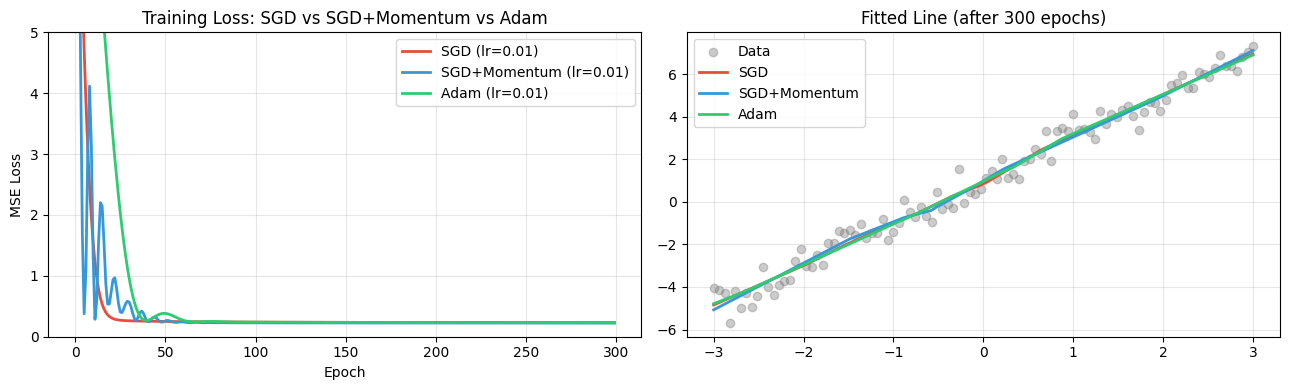

In [15]:
import torch.optim as optim

torch.manual_seed(42)

X = torch.linspace(-3, 3, 100).unsqueeze(1)
y = 2 * X + 1 + 0.5 * torch.randn_like(X)

def train_model(optimizer_name, lr, n_epochs=300):
    model = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
    criterion = nn.MSELoss()

    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == 'SGD+Momentum':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []
    for _ in range(n_epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses, model

configs = [('SGD', 0.01), ('SGD+Momentum', 0.01), ('Adam', 0.01)]
colors  = ['#E74C3C', '#3498DB', '#2ECC71']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for (name, lr), col in zip(configs, colors):
    losses, _ = train_model(name, lr)
    axes[0].plot(losses, label=f'{name} (lr={lr})', color=col, lw=2)

axes[0].set_title("Training Loss: SGD vs SGD+Momentum vs Adam")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_ylim(0, 5)

# Plot final fit — train fresh models OUTSIDE no_grad, then plot
axes[1].scatter(X.numpy(), y.numpy(), alpha=0.4, label='Data', color='gray')
for (name, lr), col in zip(configs, colors):
    _, m = train_model(name, lr)
    with torch.no_grad():                          # ← no_grad only around inference
        preds = m(X).numpy()
    axes[1].plot(X.numpy(), preds, label=name, color=col, lw=2)

axes[1].set_title("Fitted Line (after 300 epochs)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

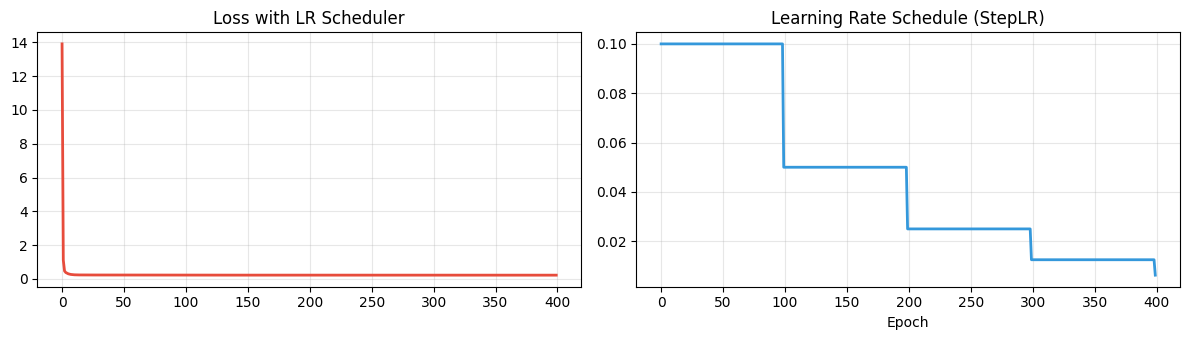

In [16]:
# ── Learning rate scheduler ──
# Reduce lr when training plateaus — very common in practice

model = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
optimizer = optim.SGD(model.parameters(), lr=0.1)

# Reduce lr by factor 0.5 every 100 epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

lrs, losses = [], []
criterion = nn.MSELoss()

for epoch in range(400):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()
    scheduler.step()        # update lr
    lrs.append(optimizer.param_groups[0]['lr'])
    losses.append(loss.item())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(losses, color='#E74C3C', lw=2)
axes[0].set_title("Loss with LR Scheduler"); axes[0].grid(alpha=0.3)
axes[1].plot(lrs, color='#3498DB', lw=2)
axes[1].set_title("Learning Rate Schedule (StepLR)")
axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 5b.5 Saving & Loading Models

```python
# Save weights
torch.save(model.state_dict(), 'model.pth')

# Load weights
model.load_state_dict(torch.load('model.pth'))
model.eval()
```


In [17]:
# Save and reload demo
torch.save(model.state_dict(), '/tmp/demo_model.pth')

# Load into a fresh model
model2 = nn.Sequential(nn.Linear(1, 16), nn.ReLU(), nn.Linear(16, 1))
model2.load_state_dict(torch.load('/tmp/demo_model.pth', weights_only=True))
model2.eval()

with torch.no_grad():
    x_test = torch.tensor([[2.0]])
    pred_original = model(x_test).item()
    pred_loaded   = model2(x_test).item()

print(f"Original model prediction: {pred_original:.6f}")
print(f"Loaded model prediction:   {pred_loaded:.6f}")
print(f"Match: {'✓' if abs(pred_original - pred_loaded) < 1e-6 else '❌'}")


Original model prediction: 5.043485
Loaded model prediction:   5.043485
Match: ✓


## ✏️ Exercises

1. **Tensors:** Create a `(4, 4)` tensor of random integers between 0 and 9. Extract the diagonal. Compute the row-wise mean.
2. **Model:** Build a `nn.Module` that has 3 hidden layers of your choice. Print the total parameter count. Run a random batch through it.
3. **Training:** Using the synthetic regression data from this notebook, train with `lr=0.1` and `lr=0.0001`. Plot both loss curves on the same axes and explain what you see.
